# CS 430 – Assignment 2: SLCM Regression Analysis
Individual take-home notebook | Target: `past_due_rent`

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
pd.set_option('display.max_columns', None)

## Part 1 – Get to Know the Prediction Problem

**1. Load the dataset and examine its structure.**
- Load the CSV file into pandas.
- Display the first 5 rows.
- Report the number of rows and columns.
- Print the column names.
- Use `info()` to inspect the dataset.

Answer: Which variable will be the target? Which columns appear to be numerical? Which columns appear to be categorical?

In [5]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/SLCM_rent_arrears_student_clean.csv')
display(df.head())
display(df.head())
print('Rows:', df.shape[0], '| Columns:', df.shape[1])
print(list(df.columns))
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,record_id,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent,past_due_rent
0,SLCM_0001,1,1,No,293.0,"Food benefits - TANF/SNAP, No income, Other",Unemployed but want to find work,No,I don't know,Yes,Other,2026-Q1,1560.0,3100.0
1,SLCM_0002,0,3,No,2000.0,Child support,Employed,No,I don't know,Yes,Unexpected expense,2026-Q3,1550.0,7300.0
2,SLCM_0003,1,0,No,400.0,Food benefits - TANF/SNAP,Unemployed but want to find work,I don't know,Yes,Yes,Lost a job/had hours cut,2025-Q4,0.0,6000.0
3,SLCM_0004,2,0,No,2500.0,Full-time employment,Unemployed and not looking for work,No,Yes,Yes,Lost a job/had hours cut,2026-Q2,1299.0,2500.0
4,SLCM_0005,1,2,No,14.0,Part-time employment,Employed,No,Yes,No,Unexpected expense,2025-Q4,1105.5,1205.5


,record_id,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent,past_due_rent
0,SLCM_0001,1,1,No,293.0,"Food benefits - TANF/SNAP, No income, Other",Unemployed but want to find work,No,I don't know,Yes,Other,2026-Q1,1560.0,3100.0
1,SLCM_0002,0,3,No,2000.0,Child support,Employed,No,I don't know,Yes,Unexpected expense,2026-Q3,1550.0,7300.0
2,SLCM_0003,1,0,No,400.0,Food benefits - TANF/SNAP,Unemployed but want to find work,I don't know,Yes,Yes,Lost a job/had hours cut,2025-Q4,0.0,6000.0
3,SLCM_0004,2,0,No,2500.0,Full-time employment,Unemployed and not looking for work,No,Yes,Yes,Lost a job/had hours cut,2026-Q2,1299.0,2500.0
4,SLCM_0005,1,2,No,14.0,Part-time employment,Employed,No,Yes,No,Unexpected expense,2025-Q4,1105.5,1205.5


Rows: 1754 | Columns: 14
['record_id', 'adults_in_household', 'children_in_household', 'household_has_65plus', 'monthly_household_income', 'income_sources', 'employment_status', 'has_housing_voucher', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter', 'monthly_rent', 'past_due_rent']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   1754 non-null   object 
 1   adults_in_household         1754 non-null   int64  
 2   children_in_household       1754 non-null   int64  
 3   household_has_65plus        1754 non-null   object 
 4   monthly_household_income    1646 non-null   float64
 5   income_sources              1754 non-null   object 
 6   employment_status           1754 non-null   object 
 7   has_housing_voucher         1754 non-null   ob

**Which variable is the target? Which columns look numerical, and which look categorical?**
The target is past_due_rent, since that’s the amount we’re trying to predict. The numerical columns are adults_in_household, children_in_household, monthly_household_income, and monthly_rent, because info() shows them as int or float and they represent counts or dollar amounts. The categorical columns are household_has_65plus, income_sources, employment_status, has_housing_voucher, eviction_in_progress, behind_on_utilities, main_reason_behind_on_rent, and intake_quarter, because they are stored as text labels (like “Yes”/”No” or an employment category). record_id is also text, but it’s only an identifier, not information about a household, so it isn’t a feature.

**2. Investigate missing values.**
- Calculate the number of missing values in every column.
- Identify which variables contain missing data.
- Briefly describe how you plan to handle those missing values before modeling.

Do not simply remove all rows with missing data unless you can justify that decision.

In [6]:
missing = df.isna().sum()
display(missing.to_frame('missing_count').assign(pct=lambda d: (d.missing_count/len(df)*100).round(2)))
print('Columns with missing data:', missing[missing > 0].index.tolist())

,missing_count,pct
record_id,0,0.00
adults_in_household,0,0.00
children_in_household,0,0.00
household_has_65plus,0,0.00
monthly_household_income,108,6.16
income_sources,0,0.00
employment_status,0,0.00
has_housing_voucher,0,0.00
eviction_in_progress,1,0.06
behind_on_utilities,7,0.40


Columns with missing data: ['monthly_household_income', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'monthly_rent']


Five columns have missing data: monthly_household_income (108 rows), main_reason_behind_on_rent (16), monthly_rent (8), behind_on_utilities (7), and eviction_in_progress (1). Dropping every row with a gap would throw away data, since income alone is about 6% of the rows, and the rest of those households’ information is still useful. Instead, I’ll fill in the missing numeric values (income, rent) with the median, which isn’t pulled around by extreme values, and fill the missing categorical values with the most common category. I’ll do this inside a pipeline so the fill values come from the training data only.


**3. Explore the target variable: `past_due_rent`.**
Calculate count, mean, median, standard deviation, minimum, maximum. Create a histogram and a boxplot.
 What does the distribution look like? Is it symmetric or skewed? Are the mean and median similar? Do you notice any unusually high values? Why might rent-arrears data naturally contain a wide range of values?

Do not automatically remove an observation simply because it is high.

,past_due_rent
count,1754.00
mean,2408.01
median,2000.00
std,2089.52
min,0.00
max,20000.00


Skewness: 2.96
Rows above 10,000: 17


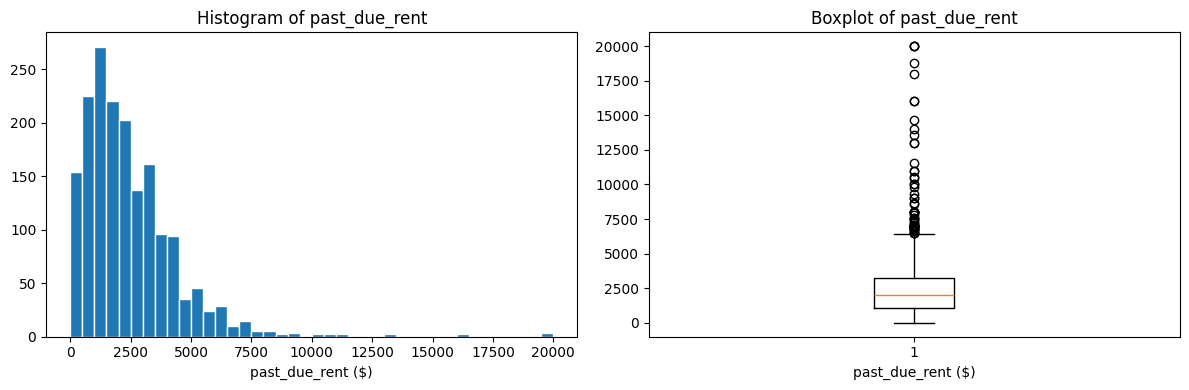

In [7]:
t = df['past_due_rent']
stats = pd.Series({'count': t.count(), 'mean': t.mean(), 'median': t.median(), 'std': t.std(), 'min': t.min(), 'max': t.max()})
display(stats.round(2).to_frame('past_due_rent'))
print('Skewness:', round(t.skew(), 2))
print('Rows above 10,000:', (t > 10000).sum())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(t, bins=40, edgecolor='white'); ax[0].set_title('Histogram of past_due_rent'); ax[0].set_xlabel('past_due_rent ($)')
ax[1].boxplot(t); ax[1].set_title('Boxplot of past_due_rent'); ax[1].set_xlabel('past_due_rent ($)')
plt.tight_layout(); plt.show()

The mean is about 2,408 and the median is 2,000, so the mean is pulled above the median. The histogram has a long tail to the right and the skewness is about 3, so the distribution is right-skewed, not symmetric. The boxplot shows a number of unusually high values, with 17 households above 10,000 and a maximum of $20,000. Rent-arrears amounts vary a lot because they depend on things like how many months a household has been behind, how high their rent is, and when they reached out for help. These high values look like real cases of households with large balances, not mistakes, so I’m keeping them.

## Part 2 – Prepare the Data for Machine Learning

**4. Create your input features and target.**
Create `X` and `y` using `past_due_rent` as the target. Do not use `record_id` as an input feature.

 Why should `record_id` not be used to predict past-due rent?

In [8]:
y = df['past_due_rent']
X = df.drop(columns=['past_due_rent', 'record_id'])
print(X.shape, y.shape)

(1754, 12) (1754,)


record_id should not be used as an input feature because it is only an identifier. It labels which row a household is, but it contains no information about their income, rent, or situation. Since every household has a different ID, a model could only memorize the training rows and would learn nothing that helps it predict a new household.

**5. Separate the numerical and categorical features.**
Create lists of numerical and categorical features and display both. Briefly explain why machine-learning models require different preparation steps for numerical and categorical variables.

In [9]:
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]
print('Numerical:', numeric_features)
print('Categorical:', categorical_features)

Numerical: ['adults_in_household', 'children_in_household', 'monthly_household_income', 'monthly_rent']
Categorical: ['household_has_65plus', 'income_sources', 'employment_status', 'has_housing_voucher', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter']


Numerical and categorical variables need different preparation because models do math on numbers. Numerical features like rent and income can be used directly, but we fill in missing values and scale them so they’re on a similar range. Categorical features like employment status are text, so they have to be converted into numbers first.Which makes a separate 0/1 “dummy” column for each category.

**6. Split the data into training and testing sets.**
Use `test_size=0.20` and `random_state=42`. Report the dimensions of `X_train`, `X_test`, `y_train`, `y_test`.

 Why should the model be evaluated using data that was not used during training?

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)

X_train: (1403, 12) | X_test: (351, 12)
y_train: (1403,) | y_test: (351,)


The model should be evaluated on data it was not trained on because it has already seen the correct answers for the training data, so its score there would look better than it really is. Testing on held-out data shows how well it predicts households it has never seen, which is what we actually care about.

**7. Prepare the numerical variables.**
Create a numerical preprocessing pipeline that handles missing values and feature scaling (e.g., `SimpleImputer`, `StandardScaler`).

Explain: How did you handle missing numerical values? Why might feature scaling matter when comparing Linear, Ridge, and Lasso models?

In [11]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

Missing numerical values were filled in using the median of each column. The median is a good choice because it isn’t pulled around by extreme values, and this data has some very high amounts. This was done inside the pipeline, so the fill values come from the training data only.Feature scaling matters because the columns have very different sizes: rent and income are in the hundreds or thousands, while the number of adults is only 0 to 5. Ridge and Lasso penalize the size of the coefficients, so without scaling the penalty would affect features unevenly just because of their units. Scaling puts all the numeric features on the same range, which makes the penalty fair and also makes the coefficients easier to compare.

**8. Prepare the categorical variables.**
Create a categorical preprocessing pipeline that handles missing values and converts text categories into numbers (e.g., `SimpleImputer`, `OneHotEncoder`).

Why can the regression models not directly use values such as employment categories? Why is one-hot encoding appropriate? Why would assigning arbitrary numbers such as 1, 2, 3, 4 to unordered categories be misleading?

In [12]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

The regression models can’t use text values like employment categories directly because they are not numbers, so the model can’t multiply or add them. One-hot encoding fixes this by creating a separate 0/1 dummy column for each category, so every category gets its own coefficient. This is appropriate for unordered categories, because the categories have no natural order. Assigning arbitrary numbers like 1, 2, 3, 4 would be misleading because the model would treat them as real numeric values, as if category 4 were bigger than category 1 or the gaps between them were equal.

**9. Combine your preprocessing steps.**
Use a `ColumnTransformer` to combine the numerical and categorical preprocessing so it can be reused inside the regression pipelines. Explain briefly why using a preprocessing pipeline is useful.

In [13]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['adults_in_household',
                                  'children_in_household',
                                  'monthly_household_income', 'monthly_rent']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['household_has_65plus', 'income_sources',
                                  'employment_status', 'has_housing_voucher',
                                  'eviction_in_progress', 'behind_on_utilities',
                                  'main_reason_behind_on_rent',
                                  'intake_quarter'])])

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


A preprocessing pipeline is useful because it computes the fill values and scaling from the training data only and then applies them to the test data in the same way. This keeps the test data truly unseen, so the accuracy we measure reflects how the model would do on new households. It also keeps preprocessing and modeling together in one object, so the same steps are reused every time we train or predict.

## Part 3 – Build and Compare Regression Models

In [15]:
def evaluate(name, model):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f'{name}: RMSE = {rmse:,.2f} | R2 = {r2:.4f}')
    return pred, rmse, r2

models, results = {}, {}

**10. Build a Multiple Linear Regression model.**
Pipeline with preprocessing + `LinearRegression`. Train, predict on the test data, calculate RMSE and R². Create an Actual vs. Predicted scatterplot (actual on x, predicted on y) with a diagonal reference line.

Answer: What does RMSE represent? What does R² tell you? How closely do predictions match actual values? Are there large prediction errors?

Linear Regression: RMSE = 1,861.21 | R2 = 0.1549


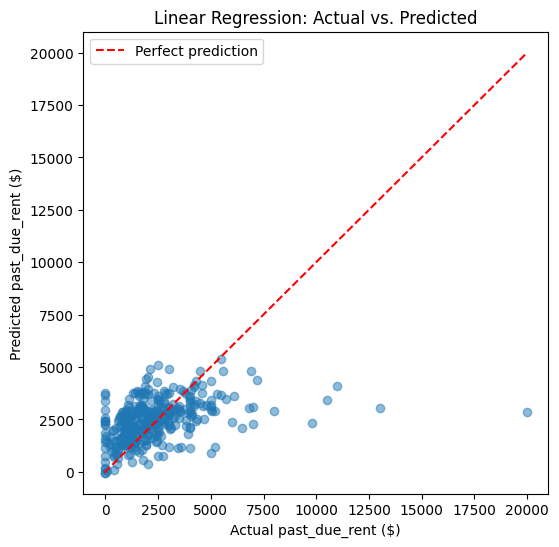

In [16]:
lin = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lin.fit(X_train, y_train)
pred_lin, rmse, r2 = evaluate('Linear Regression', lin)
models['Linear Regression'] = lin
results['Linear Regression'] = (rmse, r2)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_lin, alpha=0.5)
lims = [min(y_test.min(), pred_lin.min()), max(y_test.max(), pred_lin.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual past_due_rent ($)'); plt.ylabel('Predicted past_due_rent ($)')
plt.title('Linear Regression: Actual vs. Predicted'); plt.legend(); plt.show()

RMSE: The RMSE of about $1,861 means the model’s predictions are typically off by roughly 1,900. The standard deviation of past-due rent is about 2,027, so the model’s typical error is only slightly smaller than what you’d get by guessing the average for every household.

R²: The R² of 0.155 means the model explains only about 15% of the variation in past-due rent, so it is a weak model. Most of what determines how much a household owes is not captured by the information in this dataset.

Plot: The points are loosely scattered and mostly far from the red line. The biggest misses are for households with high actual past-due rent, where the model predicts much less than what is actually owed.

**11. Build a Polynomial Regression model.**
Use `PolynomialFeatures(degree=2, include_bias=False)` on the appropriate numerical variables only (not the one-hot columns). Train, calculate RMSE and R².

Better or worse than Linear? What does degree 2 allow that Linear cannot? Why could a very high degree overfit? Did more complexity automatically make it better?

In [17]:
poly_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
])
poly_preprocessor = ColumnTransformer([
    ('num', poly_numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])
poly = Pipeline([('prep', poly_preprocessor), ('model', LinearRegression())])
poly.fit(X_train, y_train)
pred_poly, rmse, r2 = evaluate('Polynomial Regression (degree 2)', poly)
models['Polynomial Regression'] = poly
results['Polynomial Regression'] = (rmse, r2)

# training score vs. test score, to see overfitting
print('Linear   train R2:', round(lin.score(X_train, y_train), 4), '| test R2:', round(lin.score(X_test, y_test), 4))
print('Poly     train R2:', round(poly.score(X_train, y_train), 4), '| test R2:', round(poly.score(X_test, y_test), 4))

Polynomial Regression (degree 2): RMSE = 1,875.04 | R2 = 0.1423
Linear   train R2: 0.2223 | test R2: 0.1549
Poly     train R2: 0.2301 | test R2: 0.1423


Polynomial Regression performed slightly worse than Linear Regression, with an RMSE of 1,875 compared with 1,861 and a test R² of 0.142 compared with 0.155. The two are very close in RMSE, so the difference is small. A degree-2 polynomial lets the model represent curved relationships and interactions between features, instead of only straight-line effects. A very high degree could overfit because the model starts paying attention to random noise in the training data and finding patterns that aren’t really there. Making the model more complicated did not automatically make it better here.

**12. Build a Ridge Regression model.**
Same train/test data. Choose a reasonable `alpha`; you may try more than one. Calculate RMSE and R².

How does Ridge compare with Linear? What does regularization do? Why is it useful with many features?

In [18]:
# Choose alpha using 5-fold cross-validation on the TRAINING data only
ridge_grid = GridSearchCV(
    Pipeline([('prep', preprocessor), ('model', Ridge())]),
    param_grid={'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 300, 1000]},
    cv=5, scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train, y_train)
print('Best Ridge alpha (CV):', ridge_grid.best_params_['model__alpha'])
ridge = ridge_grid.best_estimator_
pred_ridge, rmse, r2 = evaluate('Ridge Regression', ridge)
models['Ridge Regression'] = ridge
results['Ridge Regression'] = (rmse, r2)

Best Ridge alpha (CV): 50
Ridge Regression: RMSE = 1,838.17 | R2 = 0.1757


Ridge Regression performed slightly better than Linear Regression, with an RMSE of 1,838 compared with 1,861 and an R² of 0.1757 compared with 0.1549. The improvement is small. Regularization adds a penalty for large coefficients, which keeps them from growing too big and helps prevent overfitting. This is useful when a model has many features, like the 116 columns here after one-hot encoding, because it keeps the model steadier and less likely to fit noise.

**13. Build a Lasso Regression model.**
Same train/test data. Choose a reasonable `alpha`. Calculate RMSE and R².

How does Lasso compare with Linear and Ridge? What is an important difference between Ridge and Lasso? What can happen to some coefficients?

In [19]:
lasso_grid = GridSearchCV(
    Pipeline([('prep', preprocessor), ('model', Lasso(max_iter=20000))]),
    param_grid={'model__alpha': [0.1, 1, 5, 10, 25, 50, 100, 200]},
    cv=5, scoring='neg_root_mean_squared_error')
lasso_grid.fit(X_train, y_train)
print('Best Lasso alpha (CV):', lasso_grid.best_params_['model__alpha'])
lasso = lasso_grid.best_estimator_
pred_lasso, rmse, r2 = evaluate('Lasso Regression', lasso)
models['Lasso Regression'] = lasso
results['Lasso Regression'] = (rmse, r2)

coefs = lasso.named_steps['model'].coef_
print('Lasso coefficients:', len(coefs), '| exactly zero:', int((coefs == 0).sum()))
ridge_coefs = ridge.named_steps['model'].coef_
print('Ridge coefficients exactly zero:', int((ridge_coefs == 0).sum()))

Best Lasso alpha (CV): 25
Lasso Regression: RMSE = 1,831.57 | R2 = 0.1816
Lasso coefficients: 116 | exactly zero: 103
Ridge coefficients exactly zero: 0


Lasso performed slightly better than both Linear and Ridge Regression, with the lowest RMSE (1,832) and the highest R² (0.1816), although the differences are small. An important difference between Ridge and Lasso is that Ridge shrinks coefficients close to zero, while Lasso can push some of them to exactly zero. When Lasso is used, those coefficients are removed from the model entirely, so it effectively selects features. In our model, 103 of the 116 coefficients were set to zero.

**14. Compare all four models.**
Create a DataFrame with test-set RMSE and R² for all four models.

Which model has the lowest RMSE? The highest R²? Are the differences large or small? Did the most complicated model perform best? Which model would you continue investigating, and why?

In [20]:
comparison = pd.DataFrame(results, index=['RMSE', 'R²']).T.round(4)
display(comparison)
print('Lowest RMSE:', comparison['RMSE'].idxmin())
print('Highest R²:', comparison['R²'].idxmax())

,RMSE,R²
Linear Regression,1861.2128,0.1549
Polynomial Regression,1875.0364,0.1423
Ridge Regression,1838.1734,0.1757
Lasso Regression,1831.5672,0.1816


Lowest RMSE: Lasso Regression
Highest R²: Lasso Regression


Lowest RMSE and highest R²: Lasso Regression has both the lowest RMSE (1,832) and the highest R² (0.182).

Size of the differences: The differences between the models are small. RMSE only varies by about $40 across all four models, and R² ranges from 0.142 to 0.182.

Did the most complicated model perform best? No. Polynomial Regression, the most complicated model, had the highest RMSE (1,875) and the lowest R² (0.142), so added complexity did not improve prediction.

Model to continue investigating: I would continue investigating Lasso Regression. It had the best RMSE and R², and it produced the simplest model, using only 13 of the 116 features. Because the differences between the models are small, I would want to confirm this with a different train/test split before relying on it.

**15. Test your selected model on two hypothetical households.**
Create TWO new hypothetical cases (not copied from the dataset) that differ in several characteristics, then predict `past_due_rent` for both with your selected pipeline. Explain how the households differ, how different the predictions are, and whether that difference seems reasonable.

In [26]:

selected_name = 'Lasso Regression'
selected_model = models[selected_name]
print('Selected model:', selected_name)


household_A = {
    'adults_in_household': 2, 'children_in_household': 3, 'household_has_65plus': 'No',
    'monthly_household_income': 900.0, 'income_sources': 'Food benefits - TANF/SNAP',
    'employment_status': 'Unemployed but want to find work',
    'has_housing_voucher': 'No', 'eviction_in_progress': 'Yes', 'behind_on_utilities': 'Yes',
    'main_reason_behind_on_rent': 'Lost a job/had hours cut', 'intake_quarter': '2026-Q2', 'monthly_rent': 1500.0,
}

household_B = {
    'adults_in_household': 1, 'children_in_household': 0, 'household_has_65plus': 'No',
    'monthly_household_income': 3200.0, 'income_sources': 'Full-time employment',
    'employment_status': 'Employed',
    'has_housing_voucher': 'Yes', 'eviction_in_progress': "I don't know", 'behind_on_utilities': 'No',
    'main_reason_behind_on_rent': 'Unexpected expense', 'intake_quarter': '2026-Q2', 'monthly_rent': 1000.0,
}
new_households = pd.DataFrame([household_A, household_B], index=['Household A', 'Household B'])
new_households['predicted_past_due_rent'] = selected_model.predict(new_households[X.columns]).round(2)
display(new_households.T)

Selected model: Lasso Regression


,Household A,Household B
adults_in_household,2,1
children_in_household,3,0
household_has_65plus,No,No
monthly_household_income,900.0,3200.0
income_sources,Food benefits - TANF/SNAP,Full-time employment
employment_status,Unemployed but want to find work,Employed
has_housing_voucher,No,Yes
eviction_in_progress,Yes,I don't know
behind_on_utilities,Yes,No
main_reason_behind_on_rent,Lost a job/had hours cut,Unexpected expense


Household A has 2 adults and 3 children, a monthly income of 900, and rent of $1,500. The household is unemployed, has no housing voucher, is behind on utilities, and has an eviction in progress. Household B has 1 adult and no children, a monthly income of 3,200, and rent of 1,000. The person is employed, has a housing voucher, and is not behind on utilities.

The Lasso Regression model predicts that Household A owes 3,387.82 in past-due rent, while Household B owes 1,989.45. The difference is 1,398.37, with Household A predicted to owe more.

This difference seems reasonable because Household A has a much lower income, higher rent, more family members to support, and more signs of financial hardship. However, the gap is smaller than the model’s typical prediction error of about $1,800, so it should not be treated as precise. Household B is also still predicted to owe a significant amount despite its higher income and housing voucher. These predictions are estimates based on patterns in the data, not confirmed amounts, and they don’t show that any one factor causes a household to owe more.

## Part 4 – Interpret the Results

**16. What did your models tell you?**
Address: best model on the test data; approximate typical prediction error; whether Polynomial gave a meaningful improvement; whether regularization improved results; what the model predicts reasonably well; where it struggles. Use evidence from RMSE, R², visualizations, and predictions.

In [27]:
display(comparison)
print('Target std (for scale):', round(y_test.std(), 2), '| target median:', y_test.median())
resid = y_test - pred_lin
print('Largest 5 absolute linear-model errors ($):', np.sort(np.abs(resid))[-5:].round(0))

,RMSE,R²
Linear Regression,1861.2128,0.1549
Polynomial Regression,1875.0364,0.1423
Ridge Regression,1838.1734,0.1757
Lasso Regression,1831.5672,0.1816


Target std (for scale): 2027.51 | target median: 1900.0
Largest 5 absolute linear-model errors ($): [ 6889.  7084.  7463.  9965. 17171.]


Lasso Regression performed best on the test data, with an RMSE of 1,832 and an R² of 0.182. The model’s typical prediction error is about 1,800, which is only slightly smaller than the standard deviation of about 2,027 in past-due rent, so its predictions are not very precise. Polynomial Regression did not provide a meaningful improvement: its RMSE was 1,875 compared with 1,861 for Linear Regression. Regularization did improve the results, since Ridge (1,838) and Lasso (1,832) both beat Linear (1,861), but the improvement was small. The model predicts reasonably well for households with moderate balances, but it struggles with very high balances. In the Actual vs. Predicted plot, the biggest misses were households with high actual past-due rent, where the model predicted far less than what was owed. For example, the households owing over 5,000 averaged about 7,700 owed but only about $3,100 predicted.

**17. What is your overall finding for SLCM?**
In 5–8 sentences, explain your analysis to someone from SLCM who has not taken a machine-learning course: what you predicted, what information you used, how successful it was, the most important finding, whether this could help understand community needs, and one important limitation. Do not claim any input variable *causes* more or less past-due rent.

I tried to predict how much past-due rent a household owes, to see whether household, income, employment, and housing information can help predict it. I used information about each household, such as household size, monthly income, employment status, housing voucher status, utility situation, and monthly rent. The model was not very successful, because it explained only about 18% of the differences in past-due rent. The most important finding is that the model works reasonably well for households with moderate balances but badly for households with very high balances, where it predicted far less than what was owed. A model like this could still be useful for SLCM to spot general patterns in which kinds of households tend to fall behind on rent. One important limitation is that the data is missing important information, such as how many months a household is behind, which likely explains why the predictions are not very precise. The results show patterns in the data, not causes, and they should not be used to judge any individual household.